## Brain state occupancy: p_i per state and condition

In this section, the goal is to inspect the state occupancy values p_i
for each of the K = 5 brain states, separately for each subject and condition.
The features are loaded from `features_subject_condition_k5.csv` produced by script 06
(`06_assign_states_and_we.py`).

$p_i$ tells us how often the state $i$ appears; how large a proportion of time (the windows) that falls within state $i$ (occupancy).


In [1]:
import numpy as np  # numerical operations
import pandas as pd  # tabular data handling
import matplotlib.pyplot as plt  # plotting backend
import seaborn as sns  # high-level statistical plotting

# --------------------------------------------------------------------
# Configure plotting style for the entire notebook
# --------------------------------------------------------------------
sns.set_context("talk")  # slightly larger fonts for readability
sns.set_style("whitegrid")  # clean style suitable for scientific plots

# --------------------------------------------------------------------
# Path to the features CSV from script 06 (same as in original notebook)
# --------------------------------------------------------------------
features_csv = "../data/processed/wsmi/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd/states_features_k_medoids/features_subject_condition_k5.csv"  # path relative to this notebook

print("Loading features from:", features_csv)  # quick sanity check of the path

# --------------------------------------------------------------------
# Load the per-subject×condition features table
# --------------------------------------------------------------------
feat_df = pd.read_csv(features_csv)  # read CSV into a DataFrame

print("DataFrame shape:", feat_df.shape)  # (n_rows, n_columns) for a quick overview
feat_df.head()  # display the first few rows to inspect column names


Loading features from: ../data/processed/wsmi/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd/states_features_k_medoids/features_subject_condition_k5.csv
DataFrame shape: (225, 12)


,subject,condition,p_0,p_1,p_2,p_3,p_4,WE,H_occ,H_occ_norm,n_windows,condition_name
0,0,0,0.0,0.0,0.600000,0.400000,0.0,2.118537,0.673012,0.418166,10,Familiar voice
1,0,1,0.0,0.0,0.200000,0.800000,0.0,2.132007,0.500402,0.310918,10,Medical staff
2,0,2,0.0,0.0,0.666667,0.333333,0.0,2.116292,0.636514,0.395488,3,Resting
3,1,0,0.0,0.0,0.200000,0.500000,0.3,2.157336,1.029653,0.639759,10,Familiar voice
4,1,1,0.0,0.0,0.200000,0.200000,0.6,2.182665,0.950271,0.590436,10,Medical staff


In [2]:
# --------------------------------------------------------------------
# Identify the condition column (prefer human-readable names)
# --------------------------------------------------------------------
if "condition_name" in feat_df.columns:
    cond_col = "condition_name"  # use human-readable labels
elif "condition" in feat_df.columns:
    cond_col = "condition"  # numeric fallback
else:
    raise ValueError("No condition or condition_name column found in features CSV.")  # fail fast if missing

print("Using condition column:", cond_col)  # confirm which column is used

# --------------------------------------------------------------------
# Collect p_i columns corresponding to state occupancies
# --------------------------------------------------------------------
p_cols = [c for c in feat_df.columns if c.startswith("p_")]  # select all occupancy columns
p_cols = sorted(p_cols)  # ensure stable order (p_0, p_1, ..., p_4)

print("Occupancy columns:", p_cols)  # sanity check of the occupancy column names

# --------------------------------------------------------------------
# Reshape to long format: one row per subject×condition×state
# --------------------------------------------------------------------
df_states_long = feat_df.melt(
    id_vars=["subject", cond_col],  # keep subject and condition as identifiers
    value_vars=p_cols,              # unpivot the p_i columns
    var_name="state_label",         # new column holding the original p_i column name
    value_name="p",                 # new column with the corresponding occupancy value
)  # result: long table with p per state

# Extract numeric state index from labels like "p_0", "p_1", ...
df_states_long["state"] = (
    df_states_long["state_label"]           # take the string label (e.g. "p_0")
    .str.replace("p_", "", regex=False)     # strip the "p_" prefix
    .astype(int)                            # convert to integer state index
)  # now "state" is an integer in [0, 4]

# Quick check of the reshaped table
print("Long-format DataFrame shape:", df_states_long.shape)  # rows and columns
df_states_long.head(10)

# Display them all
#pd.set_option("display.max_rows", None)
#df_states_long


Using condition column: condition_name
Occupancy columns: ['p_0', 'p_1', 'p_2', 'p_3', 'p_4']
Long-format DataFrame shape: (1125, 5)


,subject,condition_name,state_label,p,state
0,0,Familiar voice,p_0,0.0,0
1,0,Medical staff,p_0,0.0,0
2,0,Resting,p_0,0.0,0
3,1,Familiar voice,p_0,0.0,0
4,1,Medical staff,p_0,0.0,0
5,1,Resting,p_0,0.0,0
6,2,Familiar voice,p_0,0.0,0
7,2,Medical staff,p_0,0.0,0
8,2,Resting,p_0,0.0,0
9,3,Familiar voice,p_0,0.0,0


**Group-level state occupancy p_i per condition**

visualising the average occupancy p_i for each of the K = 5 brain states, separately for each condition (Resting, Familiar voice, Medical staff).


State order: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Condition order: ['Resting', 'Familiar voice', 'Medical staff']


C:\Users\BMOE0112\AppData\Local\Temp\ipykernel_18308\959716374.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(


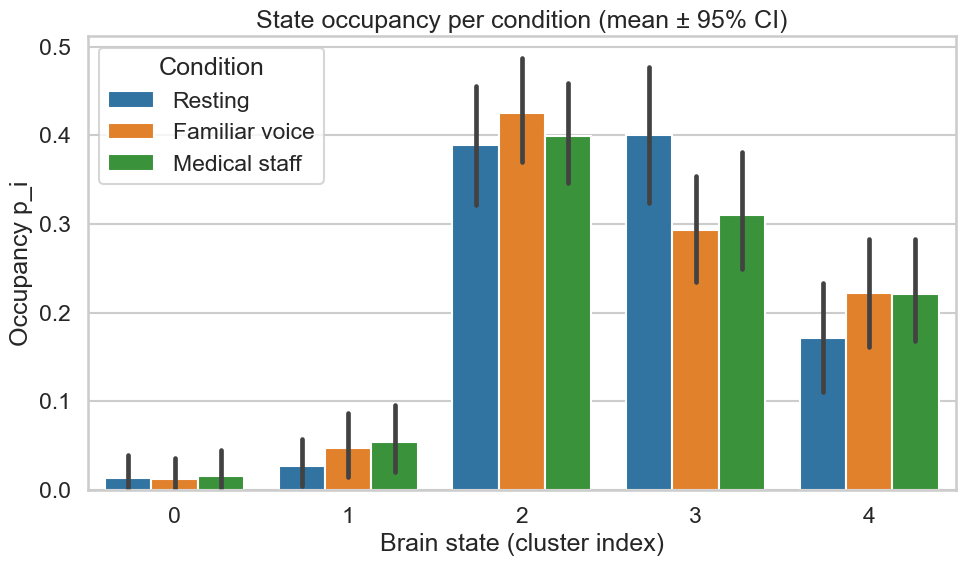

In [3]:
# --------------------------------------------------------------------
# Prepare ordering for states and conditions
# --------------------------------------------------------------------
state_order = sorted(df_states_long["state"].unique())  # ensure states are in numeric order

# Define a sensible condition order if these labels are present
default_cond_order = ["Resting", "Familiar voice", "Medical staff"]  # expected labels
unique_conds = df_states_long[cond_col].unique().tolist()  # actually present labels
cond_order = [c for c in default_cond_order if c in unique_conds]  # keep only existing ones

print("State order:", state_order)
print("Condition order:", cond_order)

# --------------------------------------------------------------------
# Barplot: mean p_i per state and condition, with 95% CI
# --------------------------------------------------------------------
plt.figure(figsize=(10, 6))  # width, height in inches

ax = sns.barplot(
    data=df_states_long,
    x="state",          # x-axis: state index (0-4)
    y="p",              # y-axis: occupancy value
    hue=cond_col,       # color-coded by condition
    order=state_order,  # enforce state order
    hue_order=cond_order,  # enforce condition order
    estimator=np.mean,  # use mean as summary statistic
    ci=95,              # 95% confidence interval
)  # create grouped barplot

ax.set_xlabel("Brain state (cluster index)")  # x-axis label
ax.set_ylabel("Occupancy p_i")  # y-axis label
ax.set_title("State occupancy per condition (mean ± 95% CI)")  # plot title

plt.legend(title="Condition")  # legend title
plt.tight_layout()  # adjust layout to avoid clipping
plt.show()  # render the figure


## State entropies $H_i$ and definition of high- and low-entropy states

In the next step, the goal is to load the entropy values $H_i$ for each of the
$K = 5$ brain states and to define two "low-entropy" and two "high-entropy"
states. These labels will later be used to compute summary measures of
state occupancy, namely:

- $p_\text{high}$: total occupancy in high-entropy states
- $p_\text{low}$: total occupancy in low-entropy states

The vector $H_i$ is loaded from `state_entropies_k5.npy` generated together
with the other features in script 06.

$H_i$ only depends on how the wSMI values are distributed within the cluster; the entropy of the connectivity pattern within state $i$.

In [4]:
import os  # used to derive paths relative to features_csv

# --------------------------------------------------------------------
# Load state entropies H_i (one value per state)
# --------------------------------------------------------------------
features_dir = os.path.dirname(features_csv)  # folder that contains the features CSV
H_path = os.path.join(features_dir, "state_entropies_k5.npy")  # adjust name if needed

print("Loading state entropies from:", H_path)

H_vec = np.load(H_path)  # shape should be (5,) for K=5 states
print("State entropies H_i:", H_vec)

# --------------------------------------------------------------------
# Identify high- and low-entropy states
# --------------------------------------------------------------------
# Sort states by entropy value (ascending)
state_indices_sorted = np.argsort(H_vec)  # from lowest to highest H_i

low_states = state_indices_sorted[:2]   # two lowest-entropy states
high_states = state_indices_sorted[-2:] # two highest-entropy states

print("Low-entropy states:", low_states)
print("High-entropy states:", high_states)


Loading state entropies from: ../data/processed/wsmi/events_tmin-0p2_tmax15_familiar_medical_resting_nice_csd/states_features_k_medoids\state_entropies_k5.npy
State entropies H_i: [2.24997807 2.17437604 2.10506716 2.13874245 2.22317164]
Low-entropy states: [2 3]
High-entropy states: [4 0]


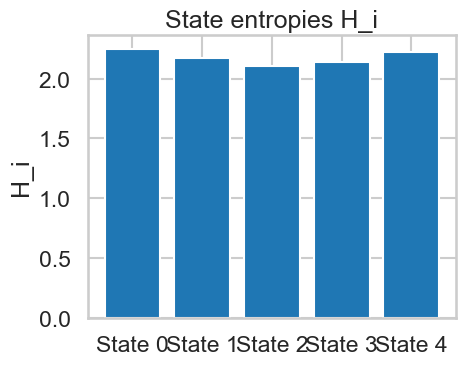

In [5]:
import matplotlib.pyplot as plt
import numpy as np

states = np.arange(len(H_vec))  # state indices 0, 1, ..., K-1

plt.figure(figsize=(5, 4))

plt.bar(states, H_vec)  # bar for each state entropy value
plt.xticks(states, [f"State {s}" for s in states])  # label x-axis with state indices
plt.ylabel("H_i")  # y-axis label for state entropy
plt.title("State entropies H_i")  # descriptive title

plt.tight_layout()
plt.show()

### Aggregate occupancy into high- and low-entropy state sets ($p_\text{high}$, $p_\text{low}$)

Given the per-state entropies $H_i$, two disjoint sets of states are defined:

- **High-entropy states**: the two states with the highest $H_i$ values.
- **Low-entropy states**: the two states with the lowest $H_i$ values.

For each subject×condition, the state occupancies $p_i$ are then aggregated into two
summary measures:

- $p_\text{high}$: summed occupancy over the high-entropy states.
- $p_\text{low}$: summed occupancy over the low-entropy states.

These quantities contrast the fraction of time the brain spends in more complex
(high-entropy) vs. more stereotyped (low-entropy) connectivity patterns.

In other words, in the cell above we sorted the states according to the state entropies -- the two lowest are called $p_{low}$ and the two highest are called $p_{high}$.


In [6]:
import numpy as np  # numerical operations

# --------------------------------------------------------------------
# Helper: aggregate occupancy over a subset of states
# --------------------------------------------------------------------
def aggregate_occupancy(row, state_indices_subset):
    """
    Sum occupancy probabilities p_i over a subset of state indices for a single row.
    """
    cols = [f"p_{int(i)}" for i in state_indices_subset]  # p_i column names for the chosen states
    return row[cols].sum()  # sum of p_i over the selected states

# --------------------------------------------------------------------
# Define K and base occupancy columns p_0, ..., p_{K-1}
# --------------------------------------------------------------------
K = len(H_vec)  # number of states (should be 5)
p_cols = [f"p_{k}" for k in range(K)]  # base occupancy columns

# Use the previously computed high_states and low_states
high_entropy_states = high_states  # indices of high-entropy states
low_entropy_states = low_states    # indices of low-entropy states

# --------------------------------------------------------------------
# Compute p_high and p_low for each subject×condition
# --------------------------------------------------------------------
feat_df["p_high"] = feat_df.apply(
    lambda row: aggregate_occupancy(row, high_entropy_states),
    axis=1,
)
feat_df["p_low"] = feat_df.apply(
    lambda row: aggregate_occupancy(row, low_entropy_states),
    axis=1,
)

# --------------------------------------------------------------------
# Preview occupancy columns including p_high and p_low (first 10 rows)
# --------------------------------------------------------------------
feat_df[["subject", cond_col] + p_cols + ["p_high", "p_low"]].head(10)


,subject,condition_name,p_0,p_1,p_2,p_3,p_4,p_high,p_low
0,0,Familiar voice,0.0,0.0,0.600000,0.400000,0.0,0.0,1.0
1,0,Medical staff,0.0,0.0,0.200000,0.800000,0.0,0.0,1.0
2,0,Resting,0.0,0.0,0.666667,0.333333,0.0,0.0,1.0
3,1,Familiar voice,0.0,0.0,0.200000,0.500000,0.3,0.3,0.7
4,1,Medical staff,0.0,0.0,0.200000,0.200000,0.6,0.6,0.4
5,1,Resting,0.0,0.0,0.000000,1.000000,0.0,0.0,1.0
6,2,Familiar voice,0.0,0.0,0.500000,0.000000,0.5,0.5,0.5
7,2,Medical staff,0.0,0.0,0.500000,0.000000,0.5,0.5,0.5
8,2,Resting,0.0,0.0,0.666667,0.333333,0.0,0.0,1.0
9,3,Familiar voice,0.0,0.0,0.500000,0.500000,0.0,0.0,1.0


## Descriptive overview of WE, H_occ_norm, p_high and p_low

In this step, the four main measures (WE, H_occ_norm, p_high and p_low) are
summarised separately for each condition (Resting, Familiar voice, Medical staff).
For each condition, the mean, standard deviation and 95% confidence interval
across subjects are reported.

In [7]:
# --------------------------------------------------------------------
# Descriptive summary for WE, H_occ_norm, p_high and p_low by condition
# --------------------------------------------------------------------
import numpy as np  # numerical operations
import pandas as pd  # data handling
from IPython.display import display  # pretty table display in notebooks

# Column with condition labels
cond_col = "condition_name"  # should already exist in feat_df

# Metrics to summarise
metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # main metrics of interest


def summarize_by_condition(df, metric, condition_col="condition_name"):
    """
    Compute mean, SD, SEM and 95% CI for one metric grouped by condition.
    """
    grouped = df.groupby(condition_col)[metric]  # group metric values by condition
    summary = grouped.agg(["mean", "std", "count"]).reset_index()  # basic stats per condition

    summary["sem"] = summary["std"] / np.sqrt(summary["count"])  # standard error of the mean
    summary["ci_low"] = summary["mean"] - 1.96 * summary["sem"]  # lower bound of 95% CI
    summary["ci_high"] = summary["mean"] + 1.96 * summary["sem"]  # upper bound of 95% CI

    summary = summary.rename(columns={"count": "n"})  # rename count column to n (number of subjects)
    return summary  # return summary table for this metric


# Loop over all metrics and show a summary table for each
for metric in metrics:
    print(f"\n=== Summary for {metric} ===")  # header for the current metric
    summary_tbl = summarize_by_condition(feat_df, metric, condition_col=cond_col)  # compute stats
    display(summary_tbl)  # show full table (all conditions)



=== Summary for WE ===


,condition_name,mean,std,n,sem,ci_low,ci_high
0,Familiar voice,2.146201,0.030944,75,0.003573,2.139198,2.153205
1,Medical staff,2.147643,0.028383,75,0.003277,2.141219,2.154067
2,Resting,2.142527,0.031263,75,0.003610,2.135451,2.149602



=== Summary for H_occ_norm ===


,condition_name,mean,std,n,sem,ci_low,ci_high
0,Familiar voice,0.425255,0.155998,75,0.018013,0.389950,0.460561
1,Medical staff,0.451750,0.181790,75,0.020991,0.410608,0.492893
2,Resting,0.313679,0.197536,75,0.022810,0.268973,0.358386



=== Summary for p_high ===


,condition_name,mean,std,n,sem,ci_low,ci_high
0,Familiar voice,0.234182,0.277875,75,0.032086,0.171293,0.297071
1,Medical staff,0.236571,0.258973,75,0.029904,0.177960,0.295183
2,Resting,0.184444,0.282860,75,0.032662,0.120427,0.248462



=== Summary for p_low ===


,condition_name,mean,std,n,sem,ci_low,ci_high
0,Familiar voice,0.718611,0.327011,75,0.037760,0.644601,0.792620
1,Medical staff,0.709206,0.302306,75,0.034907,0.640788,0.777625
2,Resting,0.788889,0.315197,75,0.036396,0.717553,0.860225


## Distribution of WE, H_occ_norm, p_high and p_low

Before choosing statistical tests, the distributions of WE, H_occ_norm, p_high
and p_low are inspected for each condition (Resting, Familiar voice, Medical staff).
This helps to see whether the measures are approximately symmetric or clearly skewed,
and whether a non-parametric approach is more appropriate.


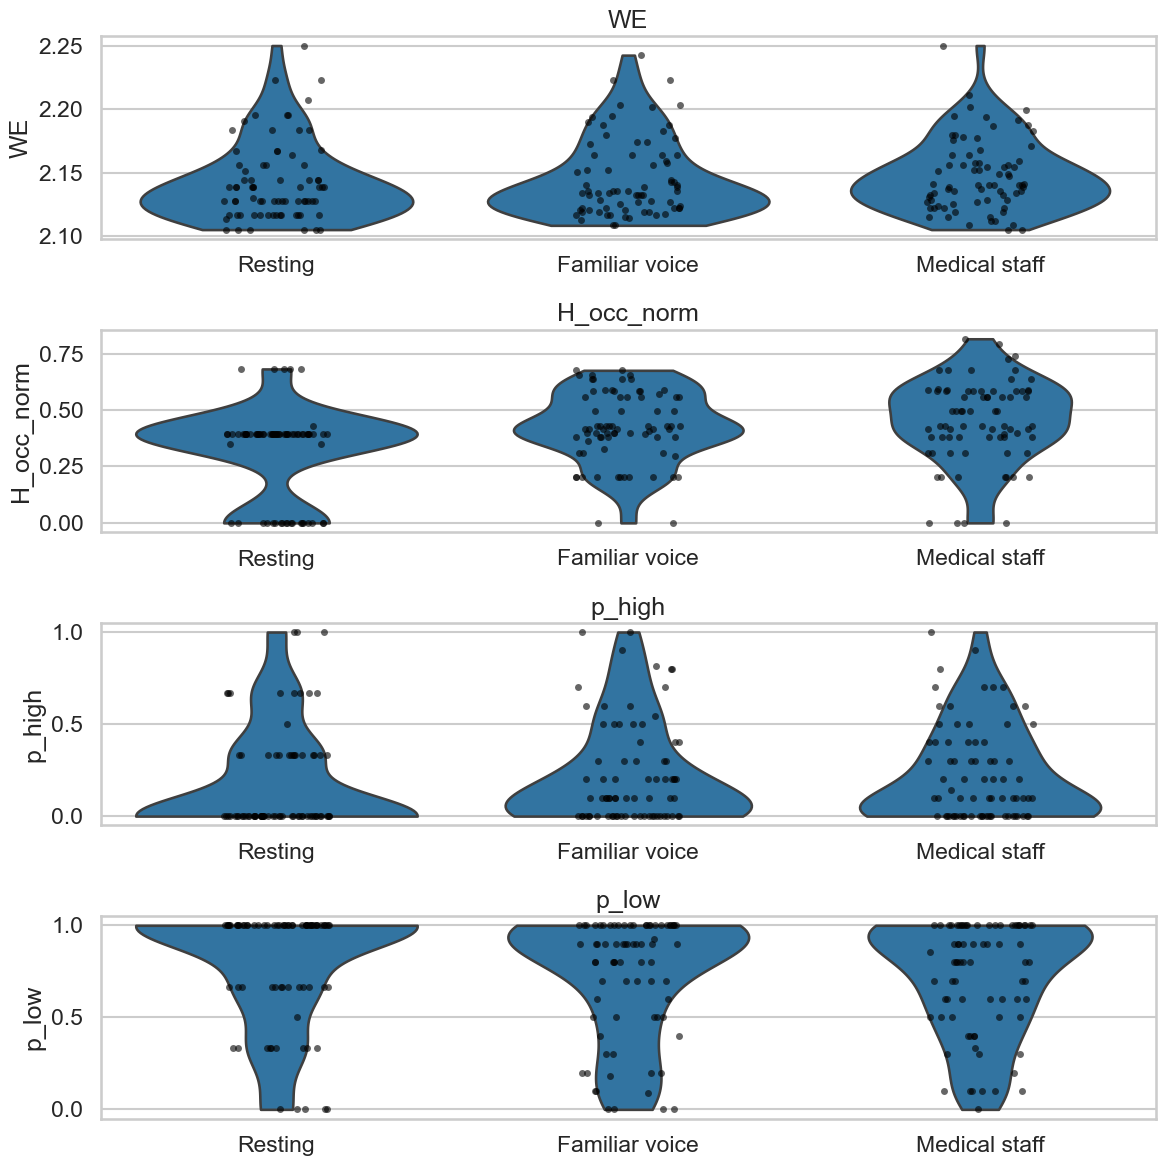

In [8]:
import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # statistical plots

# Metrics to inspect
metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # main measures
cond_col = "condition_name"  # condition label column

# --------------------------------------------------------------------
# Violin + strip plots for each metric and condition
# --------------------------------------------------------------------
n_metrics = len(metrics)  # number of subplots
plt.figure(figsize=(12, 3 * n_metrics))  # width, height scaled by number of metrics

for i, metric in enumerate(metrics, start=1):
    plt.subplot(n_metrics, 1, i)  # one row per metric

    # Violin plot to show distribution shape
    sns.violinplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=["Resting", "Familiar voice", "Medical staff"],
        inner=None,  # do not draw inner bars/points
        cut=0,  # do not extend beyond data range
    )

    # Add individual subject points on top
    sns.stripplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=["Resting", "Familiar voice", "Medical staff"],
        color="k",
        alpha=0.6,
        jitter=0.15,
    )

    plt.title(metric)
    plt.xlabel("")  # no x-label for cleaner layout
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


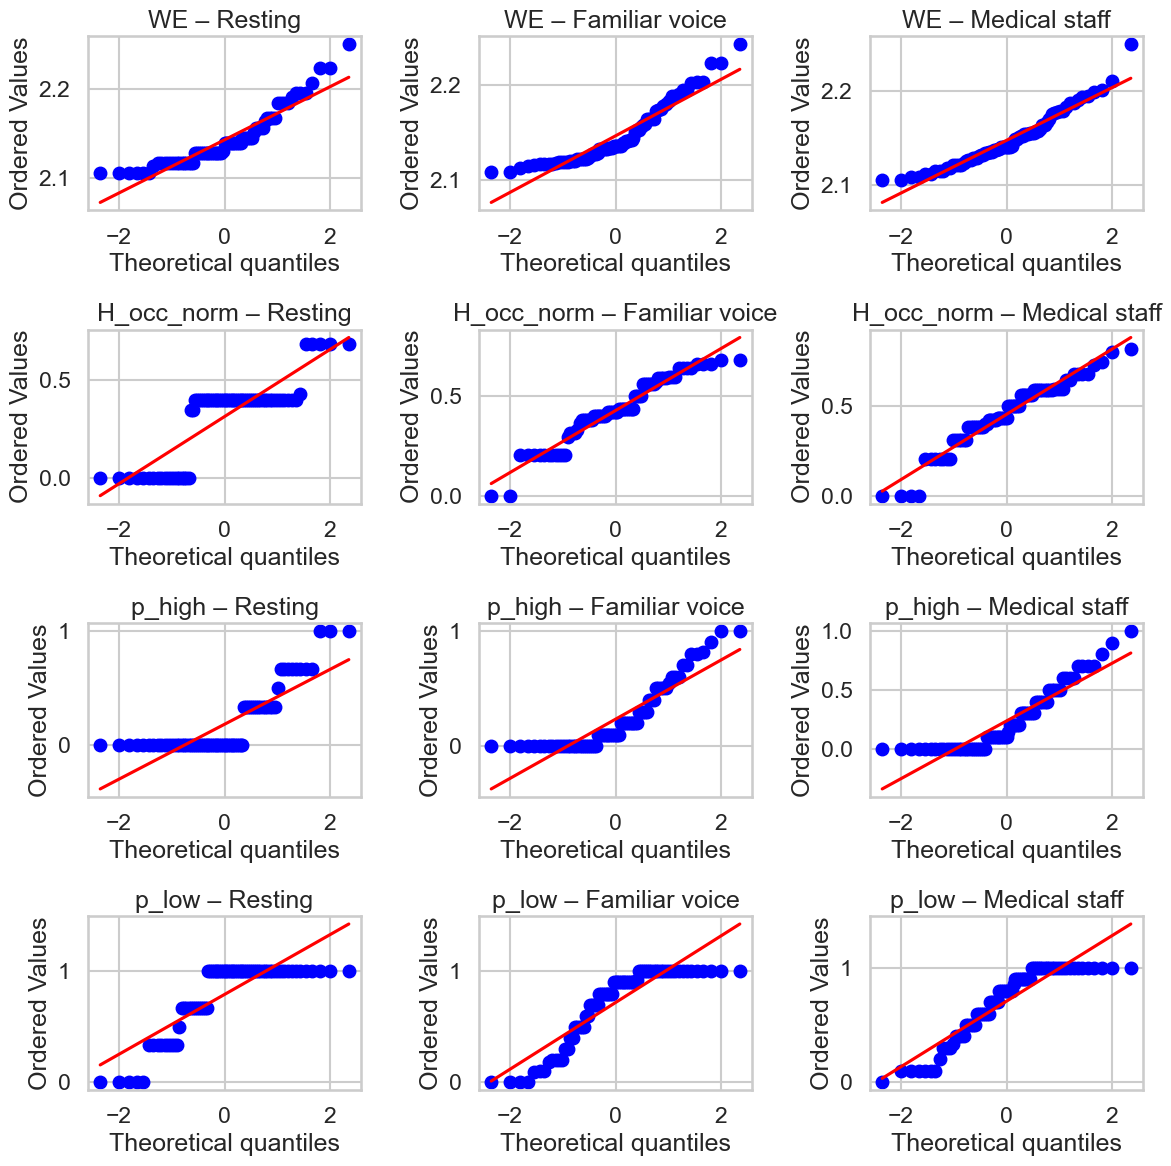

In [9]:
from scipy import stats  # for probplot
import matplotlib.pyplot as plt

metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # metrics to inspect
cond_order = ["Resting", "Familiar voice", "Medical staff"]  # expected condition labels
cond_col = "condition_name"  # column with condition labels

n_metrics = len(metrics)
n_conds = len(cond_order)

plt.figure(figsize=(4 * n_conds, 3 * n_metrics))  # width × height

for i, metric in enumerate(metrics):
    for j, cond in enumerate(cond_order):
        ax = plt.subplot(n_metrics, n_conds, i * n_conds + j + 1)

        # Extract values for this metric and condition
        vals = (
            feat_df.loc[feat_df[cond_col] == cond, metric]
            .dropna()
            .values
        )

        # Only plot if there are enough values
        if len(vals) > 1:
            stats.probplot(vals, dist="norm", plot=ax)
            ax.get_lines()[1].set_color("red")  # make reference line clearly visible
        else:
            ax.text(0.5, 0.5, "Not enough data", ha="center", va="center")
        
        ax.set_title(f"{metric} – {cond}")

plt.tight_layout()
plt.show()


## Statistical tests for WE, H_occ_norm, p_high and p_low

Based on the distributions (bounded values, visible skew and discrete steps),
non-parametric within-subject tests are used. For each measure, a Friedman test
compares the three conditions (Resting, Familiar voice, Medical staff), followed
by pairwise Wilcoxon signed-rank tests between conditions.

Friedman test:
 - A non-parametric alternative to a repeated-measures ANOVA.
 - Used when the same subjects are measured under more than two conditions.
 - It provides a single omnibus test for repeated measures without assuming normality, so you don’t have to run many separate pairwise tests (which would inflate the Type I error rate---the risk of falsely get a low p-value).

 - Used when there are more than 2 conditions (e.g. 3 brain states).
 - Used to see if there are a significanse---if yes, we continue.

 Wilcoxon signed-rank test:
  - A non-parametric alternative to the paired t-test.
  - Used for two related conditions measured on the same subjects.
  - It takes the paired differences for each subject, ranks their absolute values, and tests whether the median difference is zero.

  - Only measures to conditions at a time.
  - If we see a difference in Friedmann test, then we see WHERE are the difference.


In [10]:
from scipy import stats  # statistical tests
from statsmodels.stats.multitest import multipletests  # multiple-comparison correction

cond_order = ["Resting", "Familiar voice", "Medical staff"]
metrics = ["WE", "H_occ_norm", "p_high", "p_low"]


def metric_to_wide(df, metric, subject_col="subject", condition_col="condition_name", cond_order=None):
    """
    Convert one metric into wide format (rows = subjects, columns = conditions).
    """
    sub_df = df[[subject_col, condition_col, metric]].copy()  # keep relevant columns
    wide = sub_df.pivot(index=subject_col, columns=condition_col, values=metric)  # subject × condition

    if cond_order is not None:  # enforce column order if provided
        wide = wide.reindex(columns=cond_order)

    # Keep only subjects with valid data in all conditions
    wide = wide.dropna(axis=0, how="any")
    return wide


for metric in metrics:
    # Wide-format: rows = subjects, columns = conditions
    wide = metric_to_wide(feat_df, metric, subject_col="subject", condition_col=cond_col, cond_order=cond_order)
    data_arrays = [wide[c].values for c in cond_order]

    # Omnibus Friedman test across the three conditions
    friedman_stat, friedman_p = stats.friedmanchisquare(*data_arrays)
    print(f"{metric}: Friedman chi2 = {friedman_stat:.3f}, p = {friedman_p:.3g}")

    # Pairwise Wilcoxon tests (within-subject paired comparisons)
    pairs = [
        ("Resting", "Familiar voice"),
        ("Resting", "Medical staff"),
        ("Familiar voice", "Medical staff"),
    ]

    p_raw = []    # uncorrected p-values
    stats_W = []  # Wilcoxon W statistics

    for c1, c2 in pairs:
        x = wide[c1].values  # metric values in condition 1
        y = wide[c2].values  # metric values in condition 2

        w_stat, w_p = stats.wilcoxon(x, y, alternative="two-sided")
        stats_W.append(w_stat)
        p_raw.append(w_p)

    # Holm-Bonferroni correction for the three pairwise tests within this metric
    reject, p_corr, _, _ = multipletests(p_raw, alpha=0.05, method="holm")

    # Nicely formatted output with interpretation
    for (c1, c2), W, p_unc, p_adj, rej in zip(pairs, stats_W, p_raw, p_corr, reject):
        if p_adj < 0.05:
            note = "significant after correction Holm-Bonferroni"
        elif p_unc < 0.05:
            note = "trend (uncorrected p < 0.05, non-significant after correction Holm-Bonferroni)"
        else:
            note = "non-significant"

        print(
            f"{metric}: {c1} vs {c2}: "
            f"W = {W:.3f}, p = {p_unc:.4f}, p_corr = {p_adj:.4f} [{note}]"
        )

    print()  # blank line between metrics


WE: Friedman chi2 = 2.495, p = 0.287
WE: Resting vs Familiar voice: W = 1049.000, p = 0.0974, p_corr = 0.1948 [non-significant]
WE: Resting vs Medical staff: W = 937.000, p = 0.0507, p_corr = 0.1521 [non-significant]
WE: Familiar voice vs Medical staff: W = 1170.000, p = 0.4189, p_corr = 0.4189 [non-significant]

H_occ_norm: Friedman chi2 = 25.444, p = 2.98e-06
H_occ_norm: Resting vs Familiar voice: W = 571.000, p = 0.0000, p_corr = 0.0000 [significant after correction Holm-Bonferroni]
H_occ_norm: Resting vs Medical staff: W = 424.000, p = 0.0000, p_corr = 0.0000 [significant after correction Holm-Bonferroni]
H_occ_norm: Familiar voice vs Medical staff: W = 978.500, p = 0.1709, p_corr = 0.1709 [non-significant]

p_high: Friedman chi2 = 7.255, p = 0.0266
p_high: Resting vs Familiar voice: W = 393.500, p = 0.0183, p_corr = 0.0550 [trend (uncorrected p < 0.05, non-significant after correction Holm-Bonferroni)]
p_high: Resting vs Medical staff: W = 427.000, p = 0.0418, p_corr = 0.0837 [tre

## Key results: H_occ_norm, p_high and p_low

This section shows simple visual summaries for the three main measures
that differ between conditions: H_occ_norm, p_high and p_low. For each
measure, the distribution across subjects is shown for the three
conditions (Resting, Familiar voice, Medical staff).

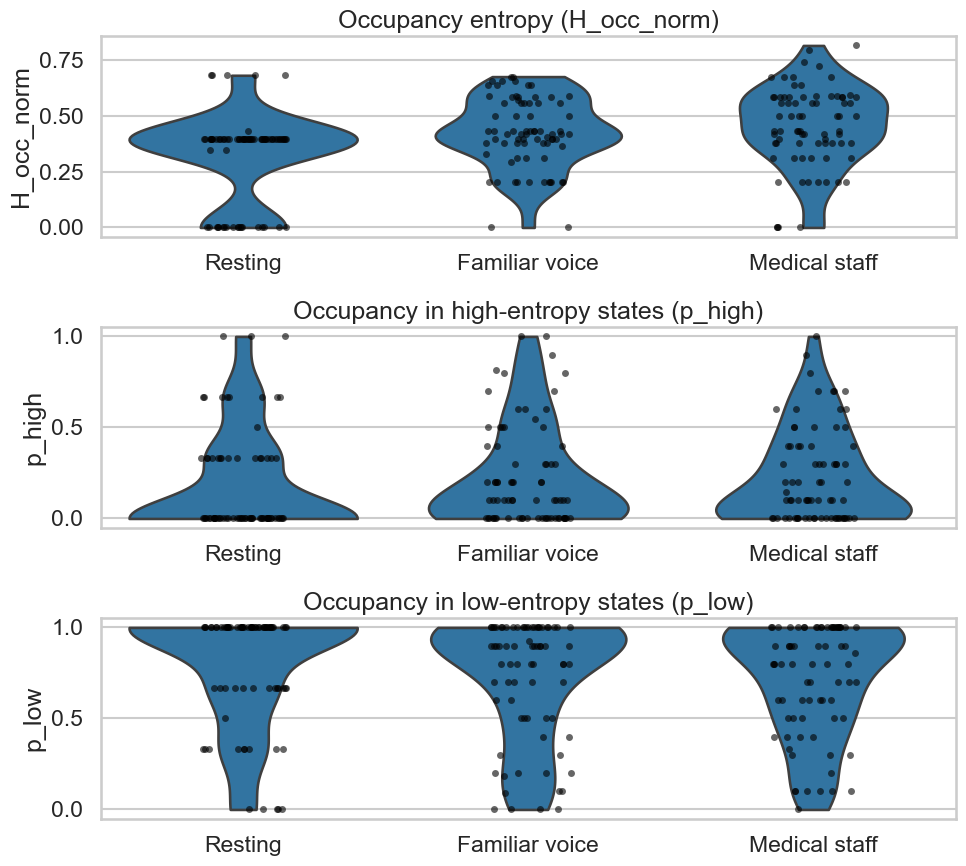

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ["H_occ_norm", "p_high", "p_low"]
metric_titles = {
    "H_occ_norm": "Occupancy entropy (H_occ_norm)",
    "p_high": "Occupancy in high-entropy states (p_high)",
    "p_low": "Occupancy in low-entropy states (p_low)",
}
cond_order = ["Resting", "Familiar voice", "Medical staff"]
cond_col = "condition_name"

n_metrics = len(metrics_to_plot)
plt.figure(figsize=(10, 3 * n_metrics))

for i, metric in enumerate(metrics_to_plot, start=1):
    plt.subplot(n_metrics, 1, i)

    # Violin plot: overall shape
    sns.violinplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=cond_order,
        inner=None,
        cut=0,
    )

    # Add individual subject points
    sns.stripplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=cond_order,
        color="k",
        alpha=0.6,
        jitter=0.15,
    )

    plt.title(metric_titles.get(metric, metric))
    plt.xlabel("")
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


## Confidence interval plots for paired mean differences

For each metric (H_occ_norm, p_low, p_high), the paired mean differences between conditions are computed (A − B) and shown together with 95% confidence intervals. A horizontal reference line at 0 corresponds to "no difference". If the confidence interval lies entirely above or below 0, the difference is considered meaningful.

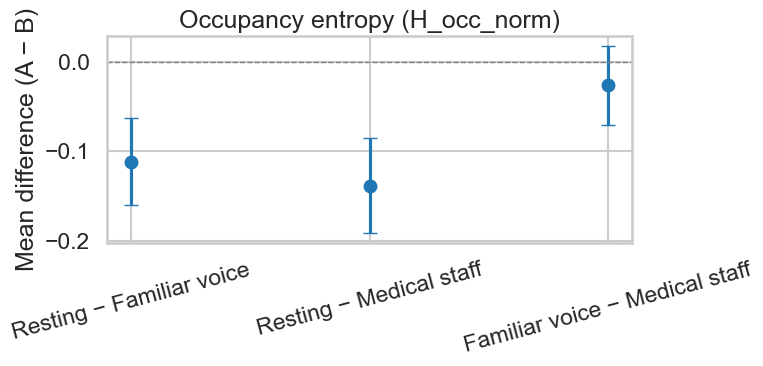

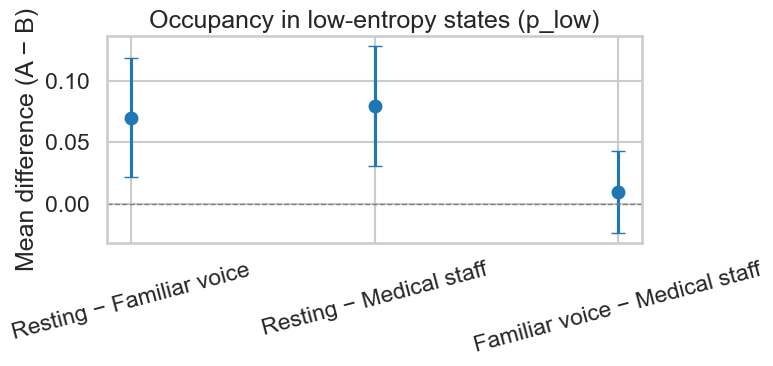

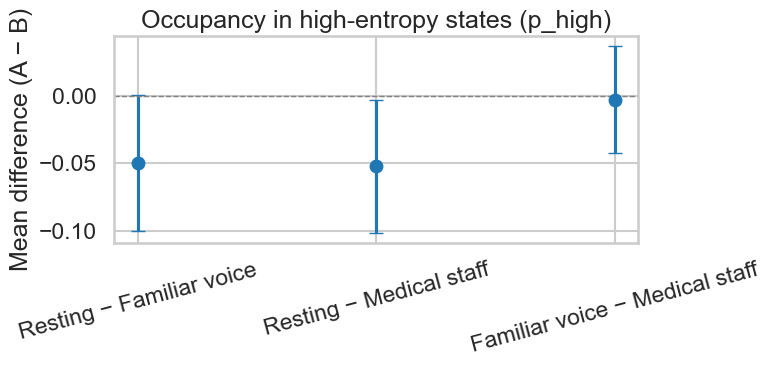

In [12]:
import numpy as np  # numerical operations
import pandas as pd  # data handling
import matplotlib.pyplot as plt  # plotting
from scipy import stats  # t-based confidence intervals


# --------------------------------------------------------------------
# Helper: compute paired mean difference and t-based 95% CI (A - B)
# --------------------------------------------------------------------
def paired_mean_diff_ci(df, metric, cond_col, cond_a, cond_b, alpha=0.05):
    """
    Compute a classical t-based confidence interval for the paired mean
    difference between two conditions (cond_a - cond_b) for a given metric.
    """
    sub_df = df[["subject", cond_col, metric]].copy()  # keep subject, condition and metric
    wide = sub_df.pivot(index="subject", columns=cond_col, values=metric)  # subject × condition table

    wide_pair = wide[[cond_a, cond_b]].dropna()  # keep only subjects with data in both conditions

    x_a = wide_pair[cond_a].to_numpy()  # values in condition A
    x_b = wide_pair[cond_b].to_numpy()  # values in condition B

    diffs = x_a - x_b  # paired differences (A - B)
    mean_diff = diffs.mean()  # observed mean difference
    sd_diff = diffs.std(ddof=1)  # sample standard deviation of differences
    n = len(diffs)  # number of paired observations

    se = sd_diff / np.sqrt(n)  # standard error of the mean difference
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)  # critical t-value for two-sided CI
    ci_low = mean_diff - t_crit * se  # lower CI bound
    ci_high = mean_diff + t_crit * se  # upper CI bound

    return mean_diff, ci_low, ci_high


# --------------------------------------------------------------------
# Metrics and condition pairs to visualise
# --------------------------------------------------------------------
metrics = ["H_occ_norm", "p_low", "p_high"]  # metrics to plot
metric_titles = {
    "H_occ_norm": "Occupancy entropy (H_occ_norm)",
    "p_low": "Occupancy in low-entropy states (p_low)",
    "p_high": "Occupancy in high-entropy states (p_high)",
}

cond_col = "condition_name"  # column with condition labels
pairs = [
    ("Resting", "Familiar voice"),
    ("Resting", "Medical staff"),
    ("Familiar voice", "Medical staff"),
]  # all pairwise comparisons

pair_labels = [f"{a} − {b}" for (a, b) in pairs]  # labels for x-axis


# --------------------------------------------------------------------
# Plot CI for mean differences (A - B) for each metric
# --------------------------------------------------------------------
for metric in metrics:
    mean_diffs = []  # list of mean differences per pair
    ci_lows = []  # list of lower CI bounds
    ci_highs = []  # list of upper CI bounds

    # Compute mean difference and CI for each condition pair
    for cond_a, cond_b in pairs:
        mean_diff, ci_low, ci_high = paired_mean_diff_ci(
            feat_df,
            metric=metric,
            cond_col=cond_col,
            cond_a=cond_a,
            cond_b=cond_b,
            alpha=0.05,
        )
        mean_diffs.append(mean_diff)
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)

    # Convert to NumPy arrays for easier handling
    mean_diffs = np.array(mean_diffs)
    ci_lows = np.array(ci_lows)
    ci_highs = np.array(ci_highs)

    # Compute asymmetric error bars relative to the mean
    err_lower = mean_diffs - ci_lows  # distance from mean to lower CI bound
    err_upper = ci_highs - mean_diffs  # distance from mean to upper CI bound
    yerr = np.vstack([err_lower, err_upper])  # shape (2, n_pairs)

    # Create the figure for this metric
    plt.figure(figsize=(8, 4))

    x_positions = np.arange(len(pairs))  # x-positions for the condition pairs

    # Errorbar plot: point for mean_diff with vertical CI
    plt.errorbar(
        x_positions,          # x-coordinates
        mean_diffs,           # y-coordinates (mean differences)
        yerr=yerr,            # asymmetric error bars
        fmt="o",              # marker style
        capsize=5,            # cap size for error bars
    )

    # Horizontal reference line at 0 (no difference)
    plt.axhline(0.0, color="grey", linestyle="--", linewidth=1)

    # Formatting of axes and labels
    plt.xticks(x_positions, pair_labels, rotation=15)
    plt.ylabel("Mean difference (A − B)")
    plt.title(metric_titles.get(metric, metric))

    plt.tight_layout()
    plt.show()


### Mean wSMI pattern for each brain state

In this step, each brain state is visualised in terms of its average wSMI
connectivity pattern. The stacked feature matrix (all windows) is combined with
the state labels to compute the mean wSMI vector for each state. These vectors
are then mapped back to (C × C) connectivity matrices using the original
channel-pair indexing and plotted as heatmaps.

The plots is an average of wSMI over all the windows for that brain state.

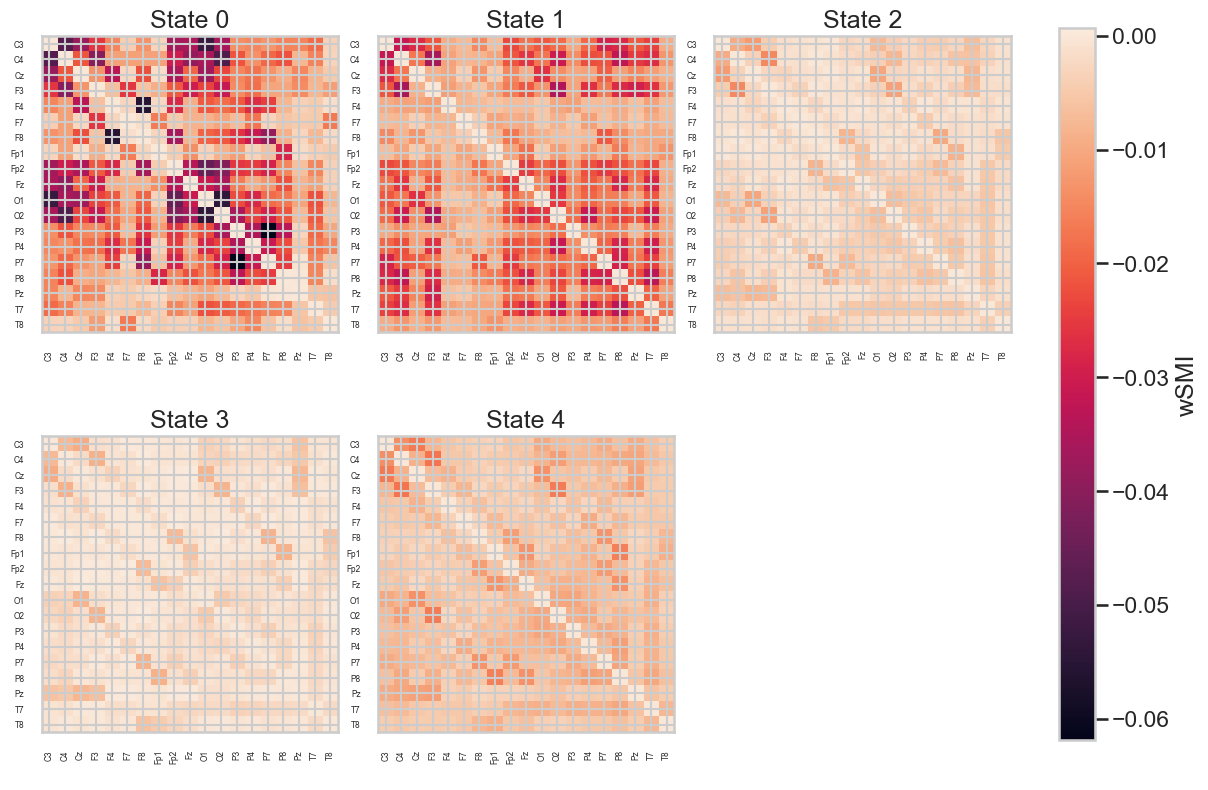

In [18]:
import numpy as np  # numerical operations
import matplotlib.pyplot as plt  # plotting

# --------------------------------------------------------------------
# Prepare layout for K states in a 2×3 grid
# --------------------------------------------------------------------
K, C, _ = state_maps.shape  # number of states and channels

n_cols = 3  # number of columns in the grid
n_rows = int(np.ceil(K / n_cols))  # number of rows, here 2 for K = 5

vmin = float(state_maps.min())  # global minimum across all states
vmax = float(state_maps.max())  # global maximum across all states

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows),  # make the figure larger and wider
    constrained_layout=True,
)

# Ensure axes is always a 2D array for indexing
axes = np.array(axes).reshape(n_rows, n_cols)

# --------------------------------------------------------------------
# Plot one connectivity matrix per state
# --------------------------------------------------------------------
for k in range(K):
    row = k // n_cols  # row index in the grid
    col = k % n_cols   # column index in the grid
    ax = axes[row, col]  # select the corresponding subplot

    im = ax.imshow(state_maps[k], vmin=vmin, vmax=vmax, interpolation="nearest")  # show matrix for state k
    ax.set_title(f"State {k}")  # title with state index

    # Show all channels but with smaller font size
    ax.set_xticks(range(C))  # x-tick positions
    ax.set_yticks(range(C))  # y-tick positions
    ax.set_xticklabels(ch_names, rotation=90, fontsize=6)  # x-axis channel labels
    ax.set_yticklabels(ch_names, fontsize=6)  # y-axis channel labels

# Turn off any unused subplots (e.g. 6th panel when K = 5)
for idx in range(K, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].axis("off")  # hide empty axis

# Add a shared colorbar for all subplots
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)  # shared colorbar
cbar.set_label("wSMI")  # label for color scale

plt.show()  # display the figure
